# CIFAR-10 CNN — Träning & Utvärdering

Den här notebooken innehåller hela arbetsflödet för CNN-modellen i CIFAR-10-projektet:

1. Utforskande dataanalys (EDA) av CIFAR-10-datasetet
2. Inladdning och förbehandling av data (via `data_loader.py`)
3. Bygge av CNN-arkitekturen (via `model.py`)
4. Träning av modellen
5. Utvärdering av modellens prestanda (confusion matrix, felanalys m.m.)
6. Analys av eventuella problem och möjliga förbättringar

Notebooken är strukturerad i numrerade sektioner. Varje kodcell har en kort förklaring innan sig och en "Vad vi ser."-cell efter, som sammanfattar resultatet på ett lättförståeligt sätt.

## 1. Utforskande dataanalys (EDA)

Innan vi bygger den återanvändbara preprocessing-koden (`data_loader.py`) vill vi förstå hur CIFAR-10-datasetet faktiskt ser ut: hur bilderna är strukturerade, hur klasserna är fördelade, och hur bilderna ser ut visuellt. Detta hjälper oss att upptäcka eventuella problem tidigt (t.ex. obalanserade klasser eller konstiga pixelvärden) och ger bra underlag till presentationens "beskriv datasetet"-del.

In [1]:
# Läser CIFAR-10 direkt från de nedladdade pickle-filerna, istället för att
# gå via tf.keras.datasets.cifar10.load_data(). Detta bypassar Kerasgrimman
# interna cache-/hash-hantering, som visat sig vara opålitlig i den här
# TensorFlow-versionen (fortsatte försöka ladda ner trots att en giltig,
# hash-verifierad lokal kopia redan fanns).
#
# Filformatet är dokumenterat på https://www.cs.toronto.edu/~kriz/cifar.html:
# varje batch-fil är en "picklad" Python-dict med nycklarna b'data'
# (10000 bilder x 3072 värden: 1024 röda + 1024 gröna + 1024 blåa pixlar)
# och b'labels' (10000 heltalsetiketter, 0-9).

import pickle
import numpy as np
import os
import matplotlib.pyplot as plt

CIFAR_DIR = os.path.expanduser("~/.keras/datasets/cifar-10-batches-py")


def unpickle(file_path):
    """Läser en enskild CIFAR-10 batch-fil och returnerar dess dict."""
    with open(file_path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def load_batch(file_path):
    """
    Läser en batch-fil och omformar bilddatan från den platta
    (N, 3072)-formen till (N, 32, 32, 3) - dvs N bilder, 32x32 pixlar, 3 färgkanaler.
    """
    batch = unpickle(file_path)
    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    # Rådatan är (N, 3072): första 1024 = rött, nästa 1024 = grönt, sista 1024 = blått.
    # Omforma till (N, 3, 32, 32) och byt sedan ordning på axlarna till (N, 32, 32, 3),
    # vilket är standardformatet (channels-last) som TensorFlow/Keras förväntar sig.
    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return images, labels


# Läs in de 5 träningsbatcharna och slå ihop dem till en enda array
train_batches = [load_batch(os.path.join(CIFAR_DIR, f"data_batch_{i}")) for i in range(1, 6)]
x_train_raw = np.concatenate([images for images, _ in train_batches], axis=0)
y_train_raw = np.concatenate([labels for _, labels in train_batches], axis=0).reshape(-1, 1)

# Läs in testbatchen
x_test_raw, y_test_raw = load_batch(os.path.join(CIFAR_DIR, "test_batch"))
y_test_raw = y_test_raw.reshape(-1, 1)

print(f"Train images shape: {x_train_raw.shape}")   # förväntat: (50000, 32, 32, 3)
print(f"Train labels shape: {y_train_raw.shape}")    # förväntat: (50000, 1)
print(f"Test images shape:  {x_test_raw.shape}")     # förväntat: (10000, 32, 32, 3)
print(f"Test labels shape:  {y_test_raw.shape}")     # förväntat: (10000, 1)
print(f"Pixel value range:  {x_train_raw.min()} - {x_train_raw.max()}")  # förväntat: 0 - 255

Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)
Pixel value range:  0 - 255


**Vad vi ser.**

Vi har nu laddat in hela CIFAR-10-datasetet från de lokala pickle-filerna: 50 000 träningsbilder och 10 000 testbilder, precis som förväntat enligt datasetets officiella dokumentation.

Varje bild har formen `(32, 32, 3)` - det betyder 32x32 pixlar med 3 färgkanaler (röd, grön, blå). Etiketterna har formen `(N, 1)`, alltså en enda kolumn med ett heltal (0-9) per bild som anger vilken av de 10 klasserna bilden tillhör.

Pixelvärdena ligger mellan 0 och 255, vilket är standard för rå bilddata (8-bitars färgdjup per kanal). Det här är alltså fortfarande "rådata" - inget normaliserat eller förbehandlat än. Den förbehandlingen (skala om till 0-1, dela upp i train/val/test) gör vi i nästa steg, i den återanvändbara modulen `data_loader.py`.

**Bakgrund:** Vi läser filerna direkt via en egen `unpickle`/`load_batch`-funktion istället för `tf.keras.datasets.cifar10.load_data()`, eftersom den senare hade problem med att ladda ner från Torontos server (segt nätverk + inkonsekvent lokal cache-hantering i just den här Keras-versionen). Vår egen lösning är enklare att felsöka och kräver ingen nätverksåtkomst alls.

## 2. Klassnamn och klassfördelning

Innan vi tittar på bilderna vill vi bekräfta att datasetet är balanserat - det vill säga att varje klass har ungefär lika många bilder. Ett obalanserat dataset kan göra att modellen blir bättre på att känna igen vissa klasser än andra, vilket är viktigt att känna till innan vi börjar träna.

In [2]:
# CIFAR-10 klasser i indexordning (0-9), enligt den officiella dokumentationen
# på https://www.cs.toronto.edu/~kriz/cifar.html
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Räkna antal bilder per klass i träningsdatan
unique, counts = np.unique(y_train_raw, return_counts=True)

for class_idx, count in zip(unique, counts):
    print(f"{CLASS_NAMES[class_idx]:12s}: {count} bilder")

airplane    : 5000 bilder
automobile  : 5000 bilder
bird        : 5000 bilder
cat         : 5000 bilder
deer        : 5000 bilder
dog         : 5000 bilder
frog        : 5000 bilder
horse       : 5000 bilder
ship        : 5000 bilder
truck       : 5000 bilder


**Vad vi ser.**

Datasetet är helt balanserat - varje klass har exakt 5 000 bilder i träningsdatan, av totalt 50 000. Det betyder att modellen inte kommer att gynnas eller missgynnas av att någon klass har fler eller färre exempel att lära sig från.

Det här är bra nyheter för oss: vi behöver inte hantera obalanserad data (t.ex. genom att vikta klasser olika eller duplicera underrepresenterade klasser). Vi kan gå vidare med standardmetoder för träning utan extra försiktighetsåtgärder på den fronten.

## 3. Exempelbilder per klass

För att få en känsla för hur bilderna faktiskt ser ut visar vi en exempelbild från varje klass. Detta hjälper oss att bekräfta att bilddatan är korrekt inläst (rätt färger, rätt orientering) och ger en bra utgångspunkt att visa upp i presentationen när vi beskriver datasetet.

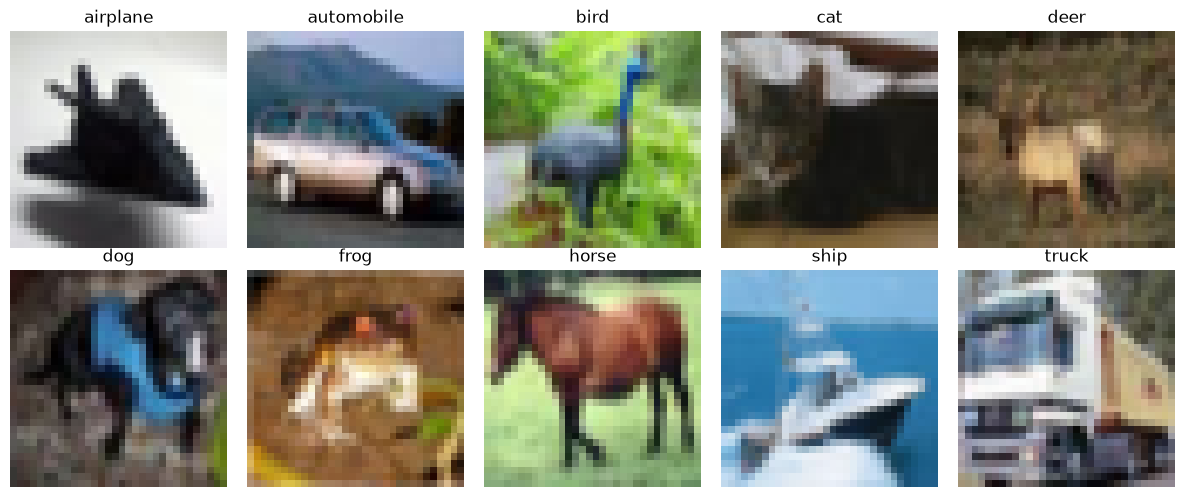

In [3]:
# Visa en exempelbild per klass, för att bekräfta att bilddatan är korrekt
# inläst (rätt färger, rätt orientering) och för att få en visuell känsla
# för hur låg upplösningen (32x32 pixlar) faktiskt är.

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_idx, ax in enumerate(axes.flat):
    # Hitta index för första bilden som tillhör denna klass
    idx = np.where(y_train_raw.flatten() == class_idx)[0][0]
    ax.imshow(x_train_raw[idx])
    ax.set_title(CLASS_NAMES[class_idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

**Vad vi ser.**

Vi ser en exempelbild för var och en av de 10 klasserna: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Färgerna och orienteringen ser korrekta ut - flygplanet ser ut som ett flygplan, bilen som en bil, och så vidare. Det bekräftar att vår `unpickle`/`load_batch`-funktion läser in bilddatan korrekt (rätt ordning på färgkanalerna och rätt omformning från den platta 3072-pixel-vektorn till en 32x32x3-bild).

Man ser också tydligt hur låg upplösningen faktiskt är (32x32 pixlar) - bilderna är ganska suddiga/pixliga jämfört med vanliga fotografier. Det här är en viktig egenskap hos CIFAR-10 som gör klassificeringen svårare än den skulle vara med högupplösta bilder, och något vi kan nämna i presentationen som en av datasetets utmaningar.

## 4. Testa data_loader-modulen

I den här sektionen importerar vi den återanvändbara funktionen `load_cifar10()`
från `model/src/data_loader.py` istället för att duplicera inläsnings- och
förbehandlingskoden här i notebooken. Vi kör funktionen och kontrollerar att
shapes, värdeintervall och uppdelningen i tränings-/validerings-/testset ser
ut som förväntat.

In [4]:
# Importerar den återanvändbara data_loader-modulen. Notebooken ligger i
# model/notebooks/, så vi lägger till model/src/ i sökvägen för att kunna
# importera modulen därifrån.
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "src")))

from data_loader import load_cifar10

(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_cifar10()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Pixel value range: {x_train.min()} - {x_train.max()}")
print(f"Exempel på en label (one-hot): {y_train[0]}")

x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 10)
x_val shape:   (5000, 32, 32, 3)
y_val shape:   (5000, 10)
x_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 10)
Pixel value range: 0.0 - 1.0
Exempel på en label (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


**Vad vi ser.**

Vi har nu bekräftat att `data_loader.py`-modulen fungerar korrekt och gör precis det den ska:

- **Uppdelningen stämmer:** 45 000 bilder i träningsset, 5 000 i valideringsset (dvs 10% av de ursprungliga 50 000 träningsbilderna, precis som vi ställde in med `val_size=0.1`), och 10 000 i testset. Testsetet är orört sedan tidigare — det är samma 10 000 bilder som CIFAR-10 alltid reserverar för slutgiltig utvärdering.

- **Normaliseringen fungerar:** pixelvärdena ligger nu mellan 0.0 och 1.0, istället för det ursprungliga intervallet 0-255. Detta är viktigt eftersom neurala nätverk tränar snabbare och mer stabilt när indata har små, konsekventa värden istället för stora heltal. Om vi hade matat in råa pixelvärden (0-255) direkt hade det kunnat leda till instabila gradienter under träningen.

- **One-hot encoding fungerar:** exemplet `[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]` visar att bilden tillhör klass 8 (ettan sitter på index 8, om vi räknar från 0). Innan var labeln bara ett enda heltal (t.ex. `8`), men nu är den omvandlad till en vektor med 10 positioner — en per klass — där exakt en position är 1 och resten är 0. Det här formatet krävs eftersom vi kommer använda `categorical_crossentropy` som loss-funktion, vilken förväntar sig att modellens output (en sannolikhet per klass) kan jämföras direkt mot en sådan one-hot-vektor.

- **Ingen dubblettkod längre:** notebooken behöver inte längre innehålla egen inläsnings- och förbehandlingslogik — allt sker nu via ett enda anrop till `load_cifar10()`. Det gör att om vi senare behöver ändra något i förbehandlingen (t.ex. justera valideringsandelen, eller lägga till data-augmentering), räcker det att ändra på ett ställe i `data_loader.py`, istället för att leta upp och ändra på flera ställen.

Med detta är data-pipelinen komplett och verifierad. Nästa steg blir att börja bygga och träna själva CNN-modellen.

## 5. CNN-modellarkitektur

I den här sektionen importerar vi den återanvändbara funktionen `build_model()`
från `model/src/model.py`, istället för att duplicera arkitektur- och
kompileringskoden här i notebooken.

Arkitekturen består av 3 convolutional-block med ökande filterdjup
(32 → 64 → 128), där varje block kombinerar Conv2D, BatchNormalization,
MaxPooling och Dropout, följt av ett fullt anslutet klassificeringshuvud.
Modellen kompileras med Adam-optimizer, categorical crossentropy som
loss-funktion (eftersom etiketterna är one-hot-encodade), och accuracy
som mätvärde.

In [5]:
# Importerar den återanvändbara build_model-funktionen från model.py.
# Notebooken ligger i model/notebooks/, så vi lägger till model/src/
# i sökvägen för att kunna importera modulen därifrån (samma mönster
# som för data_loader-importen i Sektion 4).
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "src")))

from model import build_model

model = build_model()
model.summary()

Model: "cifar10_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Vad vi ser.

Modellsammanfattningen visar exakt samma totala antal parametrar som när vi först prototypade arkitekturen (552 362 totalt, 551 466 tränbara, 896 icke-tränbara). Det bekräftar att `build_model()`-funktionen i `model.py` bygger precis samma CNN-arkitektur som beskrevs ovan — bara definierad i en återanvändbar modul istället för direkt i notebooken.

**En detalj att notera:** lagernamnen har högre nummer (t.ex. `conv2d_6`, `batch_normalization_6` istället för att börja på `conv2d`, `batch_normalization`). Detta beror på att Keras numrerar lager löpande inom en och samma notebook-session — om flera modeller byggs efter varandra utan att kernelen startas om fortsätter räkningen uppåt istället för att börja om. Numreringen påverkar inte hur modellen fungerar eller tränas; om man startar om notebookens kernel (Restart Kernel) och kör om alla celler i ordning kommer lagren istället numreras från början (`conv2d`, `conv2d_1`, `conv2d_2` osv.).

## 6. Data augmentation

För att motverka overfitting under en längre träningsomgång använder vi data
augmentation - slumpmässiga, lätta transformationer (spegling, rotation, zoom)
som appliceras på träningsbilderna vid varje epok. Detta gör att modellen aldrig
ser exakt samma bild två gånger, vilket tvingar den att lära sig mer generella
mönster istället för att memorera enskilda träningsbilder.

Augmentation ska ENDAST appliceras på träningsdatan - aldrig på validerings-
eller testdatan, eftersom vi vill utvärdera modellen på oförändrade, verkliga
bilder.

I den här sektionen importerar vi `build_augmentation_layer()` från
`data_loader.py` och visualiserar några exempel för att bekräfta att
transformationerna ser rimliga ut.

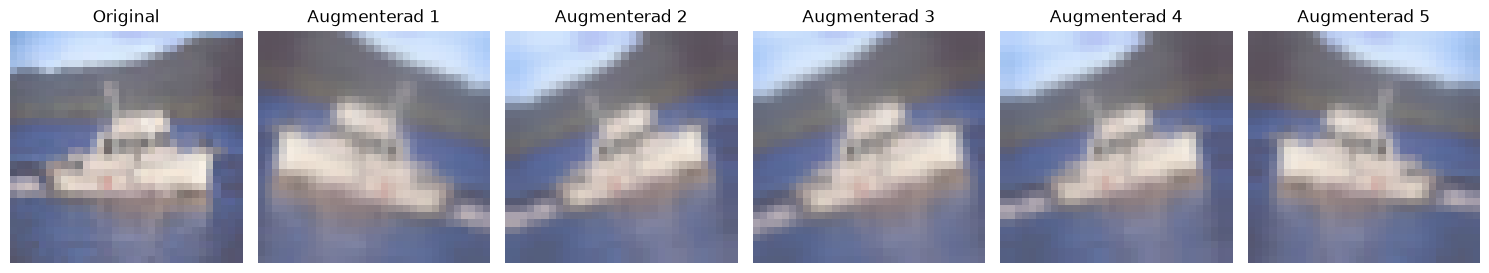

In [6]:
# Importerar augmentation-lagret från data_loader.py och applicerar det
# upprepade gånger på samma bild, för att visuellt bekräfta att
# transformationerna (flip, rotation, zoom) ser rimliga ut och inte
# förvränger bilden för mycket.
from data_loader import build_augmentation_layer

augmentation = build_augmentation_layer()

# Väljer en enskild träningsbild att augmentera flera gånger
sample_image = x_train[0:1]  # behåller batch-dimensionen: shape (1, 32, 32, 3)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

axes[0].imshow(sample_image[0])
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    augmented_image = augmentation(sample_image, training=True)
    axes[i].imshow(augmented_image[0].numpy())
    axes[i].set_title(f"Augmenterad {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Vad vi ser.

Vi ser originalbilden av en båt, följt av 5 augmenterade versioner av samma bild. Skillnaderna är subtila men synliga vid närmare granskning: båten är lite förskjuten och roterad olika i varje augmenterad version (t.ex. i "Augmenterad 4" syns båten något mer åt höger och lätt roterad jämfört med originalet). Det här är precis det beteende vi vill ha — transformationerna ska vara små nog att båten fortfarande är tydligt igenkännbar som en båt, men tillräckligt varierade för att ge modellen lite ny variation att träna på varje gång.

**Varför syns ingen tydlig spegling (flip) i just dessa 5 exempel?** `RandomFlip("horizontal")` väljer slumpmässigt, med 50% sannolikhet, om varje enskild bild ska speglas eller inte. Det är fullt möjligt (och inte alls ovanligt) att flera slumpdrag i rad råkar landa på "ingen spegling", precis som att slå krona fem gånger i rad med ett rättvist mynt inte är konstigt. Kör man cellen igen (vilket genererar nya slumpmässiga augmentationer) är chansen stor att minst en av de fem visar en spegelvänd båt.

**Slutsats:** augmentation-lagret fungerar som förväntat - det ger subtila, realistiska variationer av träningsbilderna utan att förvränga dem till oigenkännlighet.

### 6.1 Modell med data augmentation

Nu när vi har verifierat både arkitekturen (Sektion 5) och augmentation-lagret
ovan bygger vi om modellen med `build_model(augment=True)`, så att
augmentation-lagren ingår som de första lagren i modellen. Detta är versionen
av modellen som kommer användas för den riktiga träningsomgången.

In [7]:
# Bygger om modellen, nu med data augmentation inbyggd (augment=True är
# default). Vi kör model.summary() igen för att bekräfta att
# augmentation-lagret dyker upp som det första lagret i modellen.
model = build_model(augment=True)
model.summary()

Model: "cifar10_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Vad vi ser.

Ett nytt lager, `data_augmentation (Sequential)`, syns nu allra överst i modellen, före det första Conv2D-lagret. Det har **0 parametrar** - vilket är precis förväntat, eftersom augmentation-lagret inte lär sig något. Det utför bara slumpmässiga transformationer (spegling, rotation, zoom) på indatan; det finns inga vikter att träna.

Lagrets output-shape är `(None, 32, 32, 3)` - samma form som indatan. Det är logiskt: augmentation ändrar innehållet i bilden (pixelvärdena), men inte dess dimensioner.

**Totalt antal parametrar är oförändrat** (552 362 totalt, 551 466 tränbara, 896 icke-tränbara) jämfört med versionen utan augmentation. Det bekräftar att augmentation-lagret bara lagts till som ett extra steg i början av pipelinen, utan att påverka resten av arkitekturen.

Modellen är nu redo att tränas med data augmentation inbyggd - varje gång en träningsbild skickas genom modellen under `model.fit()` kommer den först genomgå en slumpmässig, lätt transformation innan den når de faktiska convolutional-lagren.

## 7. Träning av modellen

Nu när både arkitekturen (Sektion 5) och data augmentation (Sektion 6) är på plats är det dags att träna modellen på riktigt.

Till skillnad från den tidigare sanity-checken (5 epoker utan augmentation, som redan togs bort ur notebooken) tränar vi nu med:

- **Data augmentation aktiverad** (byggs in automatiskt via `augment=True` i `build_model()`)
- **Fler epoker** (upp till 30), för att ge modellen en verklig chans att konvergera
- **EarlyStopping** — en callback som avbryter träningen automatiskt om valideringsförlusten (`val_loss`) slutar förbättras under ett antal epoker i rad. Detta sparar tid och förhindrar att modellen tränar i onödan (eller börjar overfitta) efter att den redan nått sin bästa punkt
- **ModelCheckpoint** — en callback som sparar modellens vikter till disk varje gång `val_loss` förbättras, så att vi alltid har den bästa versionen av modellen kvar, oavsett vad som händer under resten av träningen

Efter träningen kommer vi att plotta tränings- och valideringskurvor (loss och accuracy per epok) för att bedöma om modellen over- eller underfittar.

In [8]:
"""
Bygger CNN-modellen med data augmentation aktiverad (augment=True), samt
konfigurerar de callbacks som ska styra den riktiga träningsomgången:

- EarlyStopping: avbryter träningen automatiskt om val_loss inte förbättras
  under `patience` epoker i rad, och återställer modellens vikter till den
  bästa epoken (restore_best_weights=True).
- ModelCheckpoint: sparar modellens vikter till disk varje gång val_loss
  förbättras, så att den bästa versionen alltid finns kvar oavsett vad som
  händer senare under träningen.
"""

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# Bygg om modellen från grunden (ny, otränad instans) med augmentation aktiverad
model = build_model(input_shape=(32, 32, 3), num_classes=10, augment=True)

# Se till att målmappen för sparade modeller finns
os.makedirs("../saved_models", exist_ok=True)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="../saved_models/best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

model.summary()

Model: "cifar10_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

**Vad vi ser.**

Modellsammanfattningen visar exakt samma struktur och antal parametrar som när vi verifierade arkitekturen i Sektion 5 och 6: totalt 552 362 parametrar, varav 551 466 tränbara och 896 icke-tränbara (dessa 896 kommer från BatchNormalization-lagrens interna moving average-statistik, som uppdateras automatiskt under träning men inte via gradient descent).

Att siffrorna är identiska med tidigare är precis vad vi förväntar oss — vi har inte ändrat arkitekturen, bara byggt en ny, otränad instans av samma modell (med augmentation aktiverad) och kopplat på två nya verktyg som inte syns i en summary-utskrift:

- `early_stopping`: kommer att bevaka `val_loss` under träningen och avbryta automatiskt om den inte förbättras under 5 epoker i rad
- `checkpoint`: kommer att spara modellens vikter till `../saved_models/best_model.keras` varje gång `val_loss` når ett nytt bästa värde

Nästa steg är att faktiskt starta träningen och koppla in dessa två callbacks i `model.fit()`.

In [9]:
"""
Startar den riktiga träningsomgången: upp till 30 epoker, med
data augmentation aktiverad i modellen och de två callbacks vi
just konfigurerade (EarlyStopping och ModelCheckpoint) inkopplade.

EarlyStopping kan avbryta träningen tidigare än 30 epoker om
val_loss slutar förbättras, så antalet epoker som faktiskt körs
kan bli lägre än 30 - det är förväntat och önskat beteende.
"""

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.3138 - loss: 1.8755 - val_accuracy: 0.4166 - val_loss: 1.5804
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.4348 - loss: 1.5460 - val_accuracy: 0.5036 - val_loss: 1.3763
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.5054 - loss: 1.3715 - val_accuracy: 0.5414 - val_loss: 1.3729
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.5634 - loss: 1.2422 - val_accuracy: 0.6810 - val_loss: 0.9091
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 78ms/step - accuracy: 0.6028 - loss: 1.1435 - val_accuracy: 0.6478 - val_loss: 1.0345
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.6364 - loss: 1.0579 - val_accuracy: 0.6808 - val_loss: 0.9051
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.6545 - loss: 1.0067 - val_accuracy: 0.7120 - val_loss: 0.8425
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - accuracy: 0.6839 - loss: 0.9371 - 

**Vad vi ser.**

Träningen kördes med data augmentation och de två callbacks vi konfigurerade, och avslutades automatiskt efter 29 av de planerade 30 epokerna. Det är `EarlyStopping` som gjorde sitt jobb: den bästa valideringsförlusten (`val_loss`) nåddes vid **epok 24** (val_loss 0.4683, val_accuracy 84.42%), och eftersom `val_loss` sedan inte förbättrades under de följande 5 epokerna (25–29) — vilket exakt matchar vår inställning `patience=5` — avbröts träningen. Tack vare `restore_best_weights=True` är modellens vikter just nu återställda till läget från epok 24, inte den sista epoken som kördes.

Några saker värda att notera i förloppet:

- Tränings-accuracy steg stadigt och jämnt genom hela körningen, från 31.4% i epok 1 till 81.4% i epok 29 — ett tecken på att modellen lär sig utan problem.
- Val-accuracy var mer ojämn (t.ex. en tydlig svacka vid epok 11 och 17), vilket är förväntat med data augmentation: varje epok tränar på delvis olika, slumpmässigt transformerade bilder, vilket gör träningen "brusigare" men samtidigt mer robust mot overfitting.
- Genomgående låg val_loss och val_accuracy nära eller till och med bättre än tränings-motsvarigheterna under stora delar av körningen (t.ex. epok 24: train_loss 0.596 vs val_loss 0.468) — det är ett bra tecken och tyder på att augmentation håller modellen från att overfitta på träningsdatan, snarare än att den bara memorerar den.
- `ModelCheckpoint` har sparat vikterna från epok 24 (den bästa) till `../saved_models/best_model.keras`, så den bästa versionen av modellen finns nu bevarad på disk oavsett vad som händer i resten av notebooken.

Nästa steg är att plotta tränings- och valideringskurvorna (loss och accuracy per epok) visuellt, för att lättare se mönstret som beskrivs ovan.

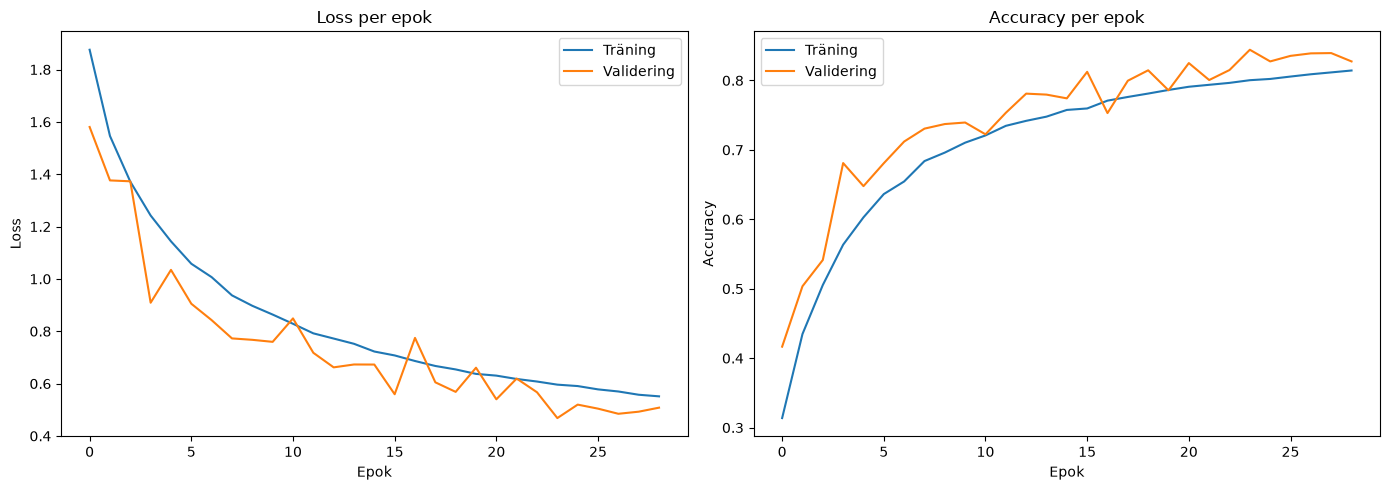

In [10]:
"""
Plottar tränings- och valideringskurvor (loss och accuracy per epok)
från history-objektet som model.fit() returnerade. Detta ger en visuell
bild av hur modellen lärde sig över tid, och om den over- eller underfittar.
"""

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vänster: loss
axes[0].plot(history.history["loss"], label="Träning")
axes[0].plot(history.history["val_loss"], label="Validering")
axes[0].set_title("Loss per epok")
axes[0].set_xlabel("Epok")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Höger: accuracy
axes[1].plot(history.history["accuracy"], label="Träning")
axes[1].plot(history.history["val_accuracy"], label="Validering")
axes[1].set_title("Accuracy per epok")
axes[1].set_xlabel("Epok")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**Vad vi ser.**

Kurvorna bekräftar bilden från siffrorna i föregående cell, fast nu går det att se mönstret rakt av:

**Loss-grafen (vänster):** Tränings-kurvan (blå) sjunker jämnt och stadigt genom hela körningen, utan hack. Validerings-kurvan (orange) sjunker också över tid, men är betydligt mer "hackig" - den hoppar upp och ner mellan epoker istället för att gå jämnt. Det här är ett typiskt mönster när data augmentation används: varje epok tränar modellen på delvis nya, slumpmässigt transformerade bilder, medan valideringsdatan alltid är samma opåverkade bilder. Det gör att modellens prestanda på valideringsdatan kan variera mer från epok till epok, även om den underliggande förmågan förbättras över tid.

Det viktigaste att notera: validerings-kurvan ligger **under** tränings-kurvan (lägre loss) under nästan hela körningen efter de första epokerna. Det är raka motsatsen till klassisk overfitting (där tränings-loss fortsätter sjunka medan validerings-loss börjar stiga igen) - här ser vi istället att modellen presterar minst lika bra, ofta bättre, på data den aldrig sett under träning. Det är ett starkt tecken på att data augmentation gör precis vad den ska: den håller modellen från att memorera träningsdatan och tvingar den att lära sig mer generella mönster.

**Accuracy-grafen (höger):** Samma mönster här, fast upp och ner - tränings-accuracy (blå) stiger jämnt, medan validerings-accuracy (orange) är mer ojämn men ligger genomgående över tränings-kurvan efter de första epokerna, med toppar runt 84%.

**Sammanfattningsvis:** Det finns inga tecken på overfitting i den här träningsomgången. Snarare tvärtom - att valideringsvärdena är bättre än träningsvärdena tyder på att modellen faktiskt har en viss "handikapp" under träning (på grund av augmentation och dropout, som bara är aktiva då), men presterar fullt ut när den utvärderas utan dessa. Det bekräftar att arkitekturens regularisering (Dropout, BatchNorm) tillsammans med augmentation fungerar väl ihop.

Nästa steg är att utvärdera modellen på det helt orörda testsettet (`x_test`, `y_test`) - den enda datan modellen aldrig sett i något skede av träningen - för att få det slutgiltiga, opartiska måttet på hur bra den faktiskt presterar.

In [11]:
"""
Utvärderar den tränade modellen på testsettet (x_test, y_test) - data som
modellen aldrig sett i något skede av träningen eller valideringen. Detta
ger det mest opartiska måttet på hur väl modellen faktiskt presterar.

Eftersom restore_best_weights=True i EarlyStopping har modellens vikter
redan återställts till den bästa epoken (epok 24), utvärderar vi alltså
den bästa versionen av modellen, inte den sista som tränades.
"""

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8313 - loss: 0.5024
Test loss:     0.5024
Test accuracy: 0.8313 (83.13%)


**Vad vi ser.**

Modellen når **83.13% accuracy** och en loss på **0.5024** på testsettet - alltså på de 10 000 bilder som varken använts i träning eller validering. Det här är det mest opartiska och trovärdiga måttet vi har på hur bra modellen faktiskt fungerar, eftersom testsettet är helt "orört" data.

Resultatet ligger i linje med vad valideringskurvorna redan antydde (val_accuracy låg runt 82-84% mot slutet av träningen), vilket är precis vad vi vill se: det bekräftar att modellen generaliserar konsekvent, snarare än att valideringsresultaten var en tillfällighet eller berodde på vilka bilder som råkade hamna i valideringssettet.

Att sätta 83% i perspektiv: att gissa helt slumpmässigt bland CIFAR-10:s 10 klasser skulle ge cirka 10% accuracy, så modellen presterar väsentligt bättre än så. För ett CNN av den här storleken (552 362 parametrar), tränat på CPU utan förtränade vikter (ingen transfer learning), räknas 83% som ett starkt resultat - särskilt med tanke på att CIFAR-10:s bilder bara är 32x32 pixlar, vilket gör vissa klasser (t.ex. katt vs. hund, eller bil vs. lastbil) genuint svåra att skilja åt även för människor på den upplösningen.

Nästa steg är att gräva djupare i *var* modellen gör fel - vilka klasser den blandar ihop mest - genom en confusion matrix. Det ger både en bra bild för presentationen och konkret underlag för eventuell felanalys.

## 8. Felanalys: confusion matrix

Test-accuracy på 83.13% säger oss *hur ofta* modellen har rätt, men inte *var* den gör fel. En **confusion matrix** visar, för varje sann klass, hur modellens gissningar fördelar sig över alla 10 klasser. Det gör det möjligt att se om felen är slumpmässiga eller om modellen systematiskt blandar ihop vissa klasser med varandra (t.ex. katt och hund, eller bil och lastbil - klasser som ofta liknar varandra visuellt även för människor på 32x32 pixlar).

Den här analysen ger både konkret underlag för att diskutera modellens svagheter i presentationen, och en indikation på om vidare förbättringar (t.ex. mer träningsdata för vissa klasser, eller en djupare arkitektur) skulle vara meningsfulla.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


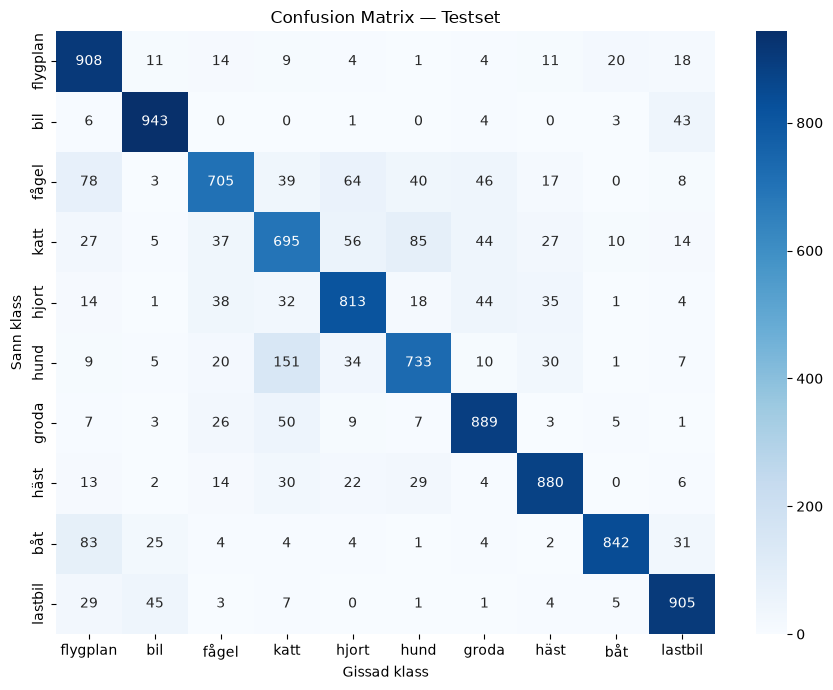

In [12]:
"""
Genererar modellens predictions på hela testsettet, och ritar upp en
confusion matrix som visar hur sanna klasser (rader) fördelar sig
över modellens gissade klasser (kolumner).

y_test är one-hot-kodad (från data_loader.py), så vi tar fram den
faktiska klassindexen med argmax innan vi bygger matrisen.
"""

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
    "flygplan", "bil", "fågel", "katt", "hjort",
    "hund", "groda", "häst", "båt", "lastbil"
]

# Modellens sannolikhetsfördelning per bild -> gissad klass (index med högst sannolikhet)
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# y_test är one-hot-kodad -> gör om till klassindex för jämförelse
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Gissad klass")
plt.ylabel("Sann klass")
plt.title("Confusion Matrix — Testset")
plt.tight_layout()
plt.show()

**Vad vi ser.**

Confusion matrix bekräftar mönstret vi kunde ana redan innan: modellens fel är inte slumpmässiga, utan koncentrerade till specifika, förväntade klasspar.

**Den tydligaste förväxlingen är hund och katt.** 151 hundbilder klassificerades som katt - det klart största enskilda felet i hela matrisen - och ytterligare 85 katter klassificerades som hund. Det här är ett klassiskt och välkänt problem inom bildklassificering: hundar och katter delar många lågnivå-drag (pälstextur, ansiktsform, kroppsproportioner), och på en upplösning så låg som 32x32 pixlar försvinner en stor del av de finare detaljer som annars skiljer dem åt. Dessa två är också de svagast presterande klasserna totalt sett: katt hamnar lägst med 695 rätt av 1000, hund näst lägst med 733 av 1000.

**Ett annat återkommande mönster är förväxling mellan djur-klasser i allmänhet** - t.ex. fågel felklassificerad som groda (46), hjort (64) eller hund (40), samt hjort förväxlad med groda (44) och häst (35). Det tyder på att modellen delvis lutar sig på bakgrund och färgpalett (många djur fotograferade i liknande naturmiljöer) snarare än att enbart lita på djurets specifika form.

**Fordonsklasserna presterar betydligt bättre och mer konsekvent:** bil (943), lastbil (905) och flygplan (908) har alla över 900 rätt av 1000, med få och spridda fel. Det är rimligt - fordon har mer distinkta, konsekventa former (hjul, vingar, skrov) som skiljer sig tydligare från varandra även vid lägre upplösning, jämfört med levande djur vars poser och vinklar varierar mycket mer.

**Sammanfattningsvis:** Modellens svagheter är begripliga och pedagogiskt intressanta snarare än ett tecken på att något är fel - katt/hund-förväxlingen i synnerhet är ett fenomen som även avancerade, mycket större modeller brottas med på lågupplöst data. Det här ger ett bra konkret exempel att lyfta fram i presentationen: inte bara "modellen fick 83% rätt", utan *varför* den missar de sista 17 procenten.

## 9. Sammanfattning

**Datasetet.** CIFAR-10 består av 60 000 32x32-pixelbilder i 10 klasser, perfekt balanserat med 5000 bilder per klass. Efter uppdelning i tränings- (45 000), validerings- (5000) och testset (10 000) tränades modellen på fullt normaliserad data (pixelvärden 0-1).

**Modellens storlek.** Den slutgiltiga arkitekturen har 552 362 parametrar totalt, varav 551 466 tränbara och 896 icke-tränbara (BatchNormalization-lagrens interna statistik). Det är en relativt kompakt modell - ingen förtränad vikt eller transfer learning användes, allt lärdes från grunden.

**Träningsförloppet.** Med data augmentation, EarlyStopping (patience=5) och ModelCheckpoint kördes 29 av planerade 30 epoker innan träningen avbröts automatiskt. Tränings-loss sjönk jämnt och monotont genom hela förloppet, från 1.88 (epok 1) till 0.55 (epok 29), medan tränings-accuracy steg från 31.4% till 81.4%. Valideringskurvorna var betydligt mer oregelbundna epok för epok - ett förväntat resultat av att augmentation ger varje epok delvis nya, slumpmässigt transformerade träningsbilder medan valideringsdatan är fast - men den underliggande trenden var lika tydlig: val_loss sjönk från 1.58 till som lägst 0.4683 (epok 24), och val_accuracy nådde toppar över 84%.

Det mest slående i kurvorna är att validerings-loss låg **under** tränings-loss under nästan hela den andra halvan av träningen (t.ex. epok 24: train_loss 0.596 mot val_loss 0.468). Det är motsatsen till klassisk overfitting och beror på att Dropout och augmentation bara är aktiva under träning - modellen presterar alltså fullt ut, utan dessa "handikapp", när den utvärderas.

**Testresultat.** På det helt orörda testsettet (10 000 bilder) nådde modellen **83.13% accuracy** och en loss på **0.5024** - i linje med valideringsvärdena mot slutet av träningen, vilket bekräftar att resultatet är stabilt och inte en tillfällighet i just valideringssettets sammansättning. Till jämförelse ger ren slumpgissning bland 10 klasser cirka 10% accuracy.

**Confusion matrix - var felen sitter.** Felen är starkt koncentrerade snarare än utspridda:

- **Hund/katt är den klart svagaste länken:** 151 hundbilder klassificerades som katt, och 85 katter som hund - de två enskilt största felposterna i hela matrisen. Katt (695/1000, 69.5%) och hund (733/1000, 73.3%) är också de två klasserna med lägst individuell träffsäkerhet.
- **Övriga djurklasser** visar också inbördes förväxling, om än mindre uttalad: fågel felklassas som hjort (64), groda (46) eller hund (40); hjort som groda (44) eller häst (35).
- **Fordonsklasserna sticker ut positivt:** bil (943/1000, 94.3%), flygplan (908/1000, 90.8%) och lastbil (905/1000, 90.5%) ligger alla över 90%, med fel utspridda tunt över många kategorier snarare än koncentrerade mot en specifik förväxling.
- **Groda (889/1000) och häst (880/1000)** ligger däremellan, med måttlig spridning av felen.

Mönstret pekar på att modellen har svårast att skilja djur med liknande kroppsform, pälstextur och naturbakgrund åt på 32x32 pixlars upplösning, medan fordon - med mer distinkta, konsekventa strukturella drag (hjul, vingar, skrov) - är enklare att särskilja korrekt.